# Data Inspection and EDA

In [74]:
from datasets import load_dataset, get_dataset_split_names
from PIL import Image
import io
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from IPython.display import display, HTML # to implement in-notebook scrolling for long print statement outputs

# Find available dataset splits (using the starter code):

In [31]:
dataset_id = "UBC-SLIME/colx585_group_project_data"

In [32]:
# From the provided sample code:

try:
    split_names = get_dataset_split_names(dataset_id)
    print(f"Available splits: {split_names}")
    
    # Load and examine each split (streaming for speed)
    for split in split_names:
        ds_split = load_dataset(dataset_id, split=split, streaming=True)
        # Get one example to check keys
        example = next(iter(ds_split))
        print(f"\n-- Split: {split} --")
        print(f"Sample ID: {example['id']}")
        print(f"Keys: {list(example.keys())}")
except Exception as e:
    print(f"Error examining splits: {e}")

Available splits: ['train', 'validation', 'test']

-- Split: train --
Sample ID: cauldron_ln_15810
Keys: ['id', 'image', 'is_member', 'type', 'text']

-- Split: validation --
Sample ID: cauldron_ln_18258
Keys: ['id', 'image', 'is_member', 'type', 'text']

-- Split: test --
Sample ID: cauldron_ln_8044
Keys: ['id', 'image', 'is_member', 'type', 'text']


# Examine the first item in "train" (using the starter code):

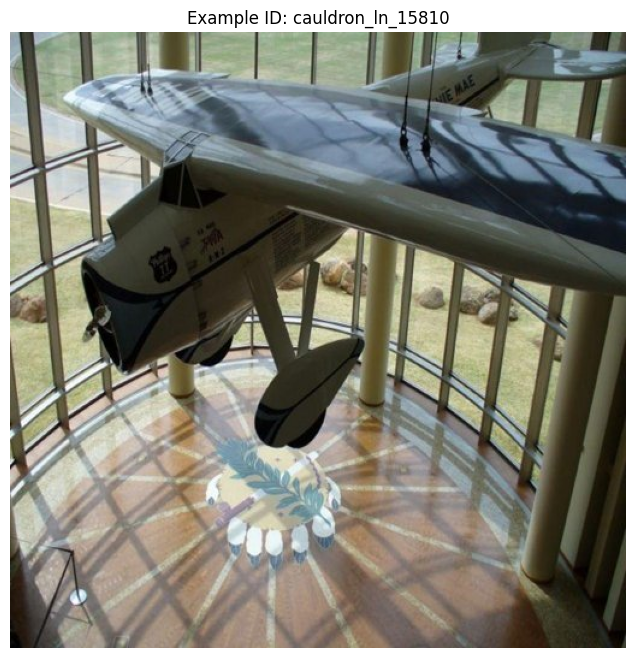

Text (full):
Please provide a concise description of this image.
At the top of this image, there is aircraft attached to the threads. Below this aircraft, there is a floor of a building having windows and pillars. In the background, there are rocks, a road and grass on the ground.


In [35]:
# From the provided sample code:

try:
    ds_train = load_dataset(dataset_id, split="train", streaming=True)
    example = next(iter(ds_train))

    # Extract image
    if isinstance(example['image'], dict) and 'bytes' in example['image']:
        image = Image.open(io.BytesIO(example['image']['bytes'])).convert("RGB")
    else:
        image = example['image'].convert("RGB")

    # Plot using matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Example ID: {example['id']}")
    plt.show()

    print(f"Text (full):\n{example['text']}")
except Exception as e:
    print(f"Error plotting image: {e}")

# Load data samples from the official data

In [53]:
# load in the data
ds = load_dataset(dataset_id)

# load in each split
train = ds["train"]
val = ds["validation"]
test = ds["test"]

# look at one example from the "train" set (custom scrolling so notebook doesn't become too long)
example = train[0]
display(HTML(f"<pre style='max-height:300px;overflow:auto'>{example}</pre>"))

# Calculate descriptive statistics

See the "Data" section of our progress report for more details.

In [51]:
stats = []

for split_name in ds.keys():
    split = ds[split_name]
    
    # text length (to calculate mean/max/min later)
    texts = split["text"]
    text_lengths = [len(t) for t in texts] # using number of characters
    
    # count how many members
    members = split["is_member"]
    member_counts = Counter(members)
    
    # find type for MIA
    types = split["type"]
    type_counts = Counter(types)
    
    # extract image dimensions (to calculate mean/max/min later)
    sample_size = min(len(split), 1000) # stop the number of images at 1000 so we don't wait forever to process
    widths, heights = [], []
    for i in range(sample_size):
        img_data = split[i]["image"]
        img = Image.open(io.BytesIO(img_data["bytes"]))
        w, h = img.size
        widths.append(w)
        heights.append(h)
    
    stats.append({
        "Split": split_name,
        "Num Samples": len(split),
        "Mean Text Length": round(sum(text_lengths) / len(text_lengths), 2),
        "Max Text Length": max(text_lengths),
        "Min Text Length": min(text_lengths),
        "Median Text Length": round(sorted(text_lengths)[len(text_lengths) // 2], 2),
        "Members (1)": member_counts.get(1, 0),
        "Non-Members (0)": member_counts.get(0, 0),
        "Member Ratio": round(member_counts.get(1, 0) / len(split), 4),
        "Types": dict(type_counts),
        "Mean Img Width": round(sum(widths) / len(widths), 1),
        "Mean Img Height": round(sum(heights) / len(heights), 1),
        "Min Img Size": f"{min(widths)}x{min(heights)}",
        "Max Img Size": f"{max(widths)}x{max(heights)}",
    })

# flatten out the "Types" dictionary to display everything in one table:
for s in stats:
    type_dict = s.pop("Types")
    for type_name, count in type_dict.items():
        s[f"Type: {type_name}"] = count

df_stats = pd.DataFrame(stats)

In [52]:
# Transposing the df so we can examine stats by train/validation/test split
df_stats = df_stats.set_index("Split").T
print(df_stats.to_string())

Split                        train validation     test
Num Samples                   6000       1200     6000
Mean Text Length             229.5     224.43   228.75
Max Text Length                776        698     1060
Min Text Length                 69         77       62
Median Text Length             214        208      214
Members (1)                   1500        300        0
Non-Members (0)               4500        900        0
Member Ratio                  0.25       0.25      0.0
Mean Img Width               512.0      512.0    512.0
Mean Img Height              512.0      512.0    512.0
Min Img Size               512x512    512x512  512x512
Max Img Size               512x512    512x512  512x512
Type: unseen_both           1500.0      300.0      NaN
Type: seen_img_unseen_txt   1500.0      300.0      NaN
Type: seen_both             1500.0      300.0      NaN
Type: unseen_img_seen_txt   1500.0      300.0      NaN
Type: None                     NaN        NaN   6000.0


# Visualization

From the statistics above, text length stands out as being quite varied. Let's visualize the text length distribution by train/validation/test split.

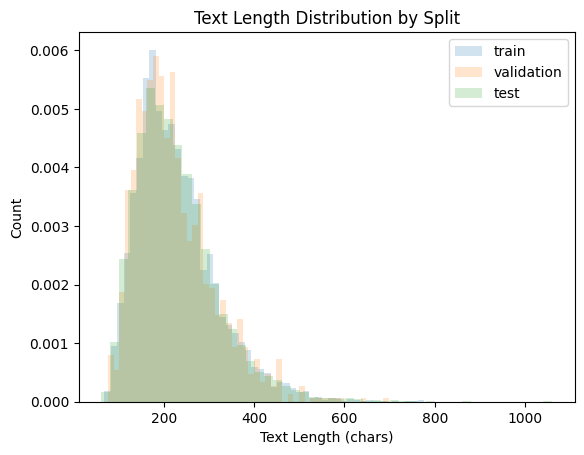

In [73]:
# Text length distribution per split
for split_name, split in ds.items():
    lengths = [len(t) for t in split["text"]]
    plt.hist(lengths, bins=50, alpha=0.2, label=split_name, density=True)
plt.xlabel("Text Length (chars)")
plt.ylabel("Count")
plt.legend()
plt.title("Text Length Distribution by Split")
plt.show()